#Analisi e pulizia dei dati

In [ ]:
# --- 1. SETUP & RAW DATA LOADING ---
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
import tensorflow as tf

# Reproducibility Seeds
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Download Dataset
# Ensure both True.csv and Fake.csv are unzipped if they don't exist
if not os.path.exists('True.csv'):
    os.system('unzip -q -o /content/True.csv.zip')
if not os.path.exists('Fake.csv'):
    os.system('unzip -q -o /content/Fake.csv.zip')

# Load Raw Data
df_true = pd.read_csv('True.csv')
df_fake = pd.read_csv('Fake.csv')

# Labeling
df_true['target'] = 0  # True News
df_fake['target'] = 1  # Fake News

# Inspection of Raw Data
print("--- ISPEZIONE DATI GREZZI ---")
print(f"Esempio 'True News' (Raw):")
print(df_true['text'].iloc[0][:100]) # Stampiamo i primi 100 caratteri
print(f"\nEsempio 'Fake News' (Raw):")
print(df_fake['text'].iloc[0][:100])

# Merge & Shuffle
df = pd.concat([df_true, df_fake]).sample(frac=1, random_state=SEED).reset_index(drop=True)
print(f"\nDataset unito: {df.shape} righe.")

--- ISPEZIONE DATI GREZZI ---
Esempio 'True News' (Raw):
WASHINGTON (Reuters) - The head of a conservative Republican faction in the U.S. Congress, who voted

Esempio 'Fake News' (Raw):
Donald Trump just couldn t wish all Americans a Happy New Year and leave it at that. Instead, he had

Dataset unito: (44898, 5) righe.


In [ ]:
# --- 2. DATA FORENSICS: SOURCE BIAS DETECTION ---

# Contiamo quante notizie VERE contengono la firma esplicita "Reuters"
reuters_in_true = df[df['target'] == 0]['text'].str.contains('Reuters', case=False).sum()
total_true = len(df[df['target'] == 0])

# Contiamo quante notizie FALSE contengono la firma "Reuters"
reuters_in_fake = df[df['target'] == 1]['text'].str.contains('Reuters', case=False).sum()
total_fake = len(df[df['target'] == 1])

print("--- ANALISI DEL BIAS DELLA FONTE ---")
print(f"Articoli 'True' contenenti 'Reuters': {reuters_in_true} su {total_true} ({reuters_in_true/total_true:.1%})")
print(f"Articoli 'Fake' contenenti 'Reuters': {reuters_in_fake} su {total_fake} ({reuters_in_fake/total_fake:.1%})")

# Visualizzazione del problema
if reuters_in_true / total_true > 0.9:
    print("\n[!] CRITICITÀ RILEVATA: Il dataset presenta un grave 'Source Bias'.")
    print("    Il modello potrebbe imparare a leggere la firma 'Reuters' invece del contenuto.")

--- ANALISI DEL BIAS DELLA FONTE ---
Articoli 'True' contenenti 'Reuters': 21378 su 21417 (99.8%)
Articoli 'Fake' contenenti 'Reuters': 322 su 23481 (1.4%)

[!] CRITICITÀ RILEVATA: Il dataset presenta un grave 'Source Bias'.
    Il modello potrebbe imparare a leggere la firma 'Reuters' invece del contenuto.


In [ ]:
# --- 3. PREPROCESSING CORRETTIVO ---

def clean_text_robust(text):
    """
    Pulisce il testo rimuovendo pattern specifici che causano data leakage.
    Target primario: Firme di agenzia (es. "WASHINGTON (Reuters) -").
    """
    text = str(text).lower()

    # 1. Rimozione Firma Reuters e Città (Pattern: "Città (Reuters) -")
    text = re.sub(r'^[a-z\s]+ \(reuters\) -', '', text)
    text = re.sub(r'^[a-z\s]+ -', '', text)

    # 2. Pulizia Standard
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\n', ' ', text)

    return text.strip()

print("Applicazione della pulizia correttiva...")
df['text_clean'] = df['text'].apply(clean_text_robust)

# Verifica post-pulizia
print("\n--- VERIFICA POST-PULIZIA ---")
print(f"Originale: {df_true['text'].iloc[0][:50]}...")
print(f"Pulito:    {clean_text_robust(df_true['text'].iloc[0])[:50]}...")

Applicazione della pulizia correttiva...

--- VERIFICA POST-PULIZIA ---
Originale: WASHINGTON (Reuters) - The head of a conservative ...
Pulito:    the head of a conservative republican faction in t...


/tmp/ipython-input-483646604.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target', data=df, palette=['#4c72b0', '#c44e52']) # Blu (True) e Rosso (Fake)


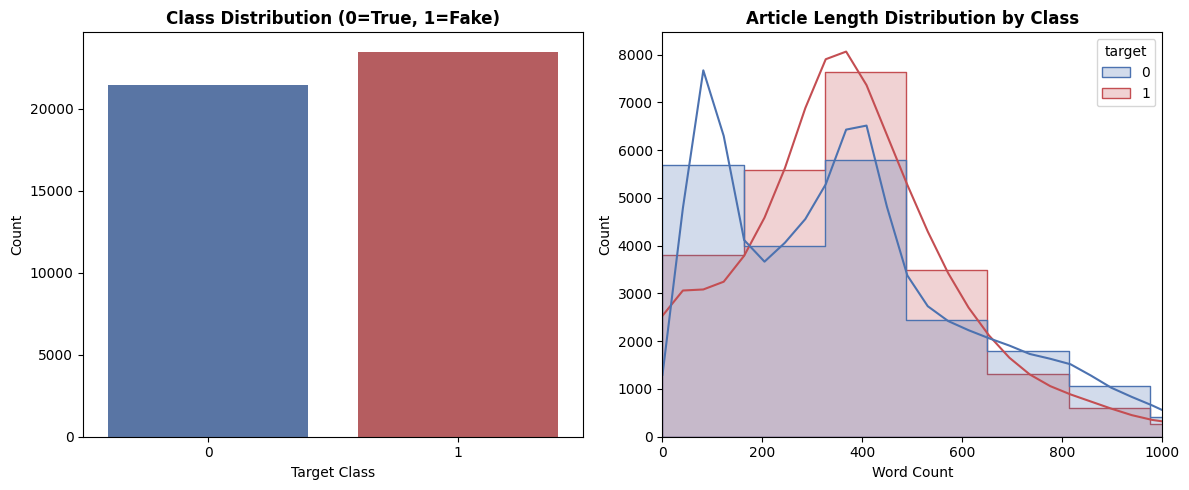


Generazione Word Clouds...


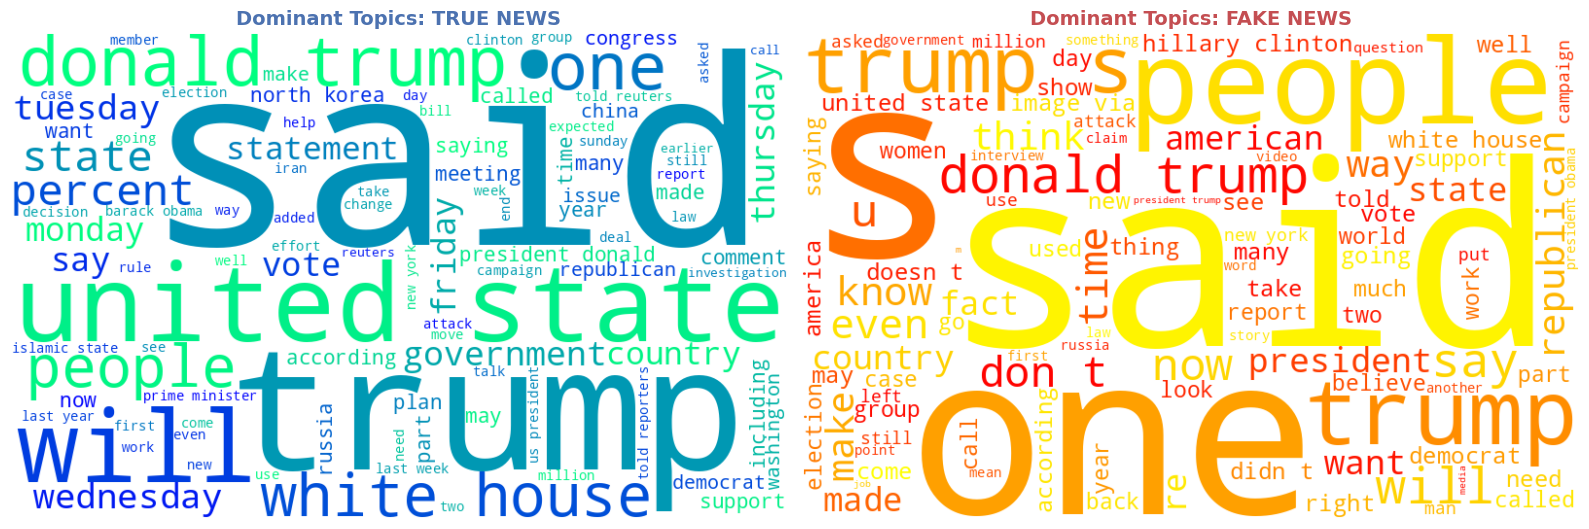

Analisi Visiva Completata. Si noti l'assenza di firme di agenzia dominanti nelle True News.


In [ ]:
# --- BLOCCO 2: VISUAL EXPLORATORY DATA ANALYSIS (EDA) ---
from wordcloud import WordCloud

# Configurazione Grafica
plt.figure(figsize=(12, 5))

# 1. Class Balance Check
# Dimostriamo che il dataset non è sbilanciato (fondamentale per la validità delle metriche)
plt.subplot(1, 2, 1)
sns.countplot(x='target', data=df, palette=['#4c72b0', '#c44e52']) # Blu (True) e Rosso (Fake)
plt.title('Class Distribution (0=True, 1=Fake)', fontsize=12, fontweight='bold')
plt.xlabel('Target Class')
plt.ylabel('Count')

# 2. Text Length Distribution
# Vediamo se c'è una differenza sistematica nella lunghezza (che potrebbe causare bias)
df['word_count'] = df['text_clean'].apply(lambda x: len(str(x).split()))
plt.subplot(1, 2, 2)
sns.histplot(data=df, x='word_count', hue='target', bins=50, kde=True, palette=['#4c72b0', '#c44e52'], element="step")
plt.title('Article Length Distribution by Class', fontsize=12, fontweight='bold')
plt.xlabel('Word Count')
plt.xlim(0, 1000) # Limitiamo per leggibilità
plt.tight_layout()
plt.show()

# 3. Word Clouds (Evidence of Content)
# Generiamo le nuvole di parole per vedere se la pulizia ha rimosso "Reuters"
print("\nGenerazione Word Clouds...")
text_true = " ".join(df[df['target'] == 0]['text_clean'])
text_fake = " ".join(df[df['target'] == 1]['text_clean'])

plt.figure(figsize=(16, 8))

# WordCloud True News
plt.subplot(1, 2, 1)
wc_true = WordCloud(background_color='white', width=800, height=500, max_words=100, colormap='winter').generate(text_true)
plt.imshow(wc_true, interpolation='bilinear')
plt.axis('off')
plt.title("Dominant Topics: TRUE NEWS", fontsize=14, fontweight='bold', color='#4c72b0')

# WordCloud Fake News
plt.subplot(1, 2, 2)
wc_fake = WordCloud(background_color='white', width=800, height=500, max_words=100, colormap='autumn').generate(text_fake)
plt.imshow(wc_fake, interpolation='bilinear')
plt.axis('off')
plt.title("Dominant Topics: FAKE NEWS", fontsize=14, fontweight='bold', color='#c44e52')

plt.tight_layout()
plt.show()

print("Analisi Visiva Completata. Si noti l'assenza di firme di agenzia dominanti nelle True News.")

# Machine learning

In [ ]:
# --- BLOCCO 3: MACHINE LEARNING BASELINE COMPLETO & CECITÀ SEMANTICA ---

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score
import time

# 1. Feature Extraction (Approccio Bag-of-Words)
print("Vettorizzazione TF-IDF (Top 5000 parole)...")
vectorizer = TfidfVectorizer(max_features=5000)
X_tfidf = vectorizer.fit_transform(df['text_clean'])
y = df['target'].values

# Split Train/Test (80/20)
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.2, random_state=SEED)

# 2. Addestramento Benchmark (5 Modelli)
# Includiamo tutti i modelli presenti nell'analisi originale per completezza
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=SEED),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5), #
    "Decision Tree": DecisionTreeClassifier(max_depth=20, random_state=SEED), # [cite: 290]
    "Random Forest": RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=SEED), #
    "Linear SVM": LinearSVC(dual='auto', random_state=SEED) # [cite: 329]
}

results = {}
trained_models = {}

print("\n--- TRAINING & EVALUATION BENCHMARK ---")
for name, model in models.items():
    start_time = time.time()
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    acc = accuracy_score(y_test, pred)
    elapsed = time.time() - start_time

    results[name] = acc
    trained_models[name] = model
    print(f"{name:20} | Accuracy: {acc*100:.2f}% | Time: {elapsed:.2f}s")

# 3. INTERPRETABILITÀ: Analisi dei Pesi (Logistic Regression)
# Utile per vedere le parole "Trigger"
print("\n--- ANALISI DEI PESI (Logistic Regression) ---")
lr_model = trained_models['Logistic Regression']
feature_names = vectorizer.get_feature_names_out()
coefs = lr_model.coef_[0]

word_imp = pd.DataFrame({'Word': feature_names, 'Weight': coefs})
top_fake = word_imp.sort_values(by='Weight', ascending=False).head(5)
top_true = word_imp.sort_values(by='Weight', ascending=True).head(5)

print("Top parole per FAKE (Weight > 0):\n", top_fake['Word'].values)
print("Top parole per TRUE (Weight < 0):\n", top_true['Word'].values)

# 4. STRESS TEST SEMANTICO (Il fallimento collettivo)
def test_semantic_blindness(model, vectorizer, model_name):
    """
    Dimostra che il modello, pur avendo alta accuratezza, non legge la sintassi.
    """
    real_text = "The central bank kept interest rates unchanged to maintain stability."
    # Stesse parole, ordine caotico
    salad_text = "Stability rates unchanged maintain interest bank central kept the."

    vecs = vectorizer.transform([clean_text_robust(real_text), clean_text_robust(salad_text)])

    # Gestione output score per diversi tipi di modelli
    if hasattr(model, "decision_function"):
        scores = model.decision_function(vecs)
    elif hasattr(model, "predict_proba"):
        scores = model.predict_proba(vecs)[:, 1]
    else:
        scores = model.predict(vecs) # Fallback (es. KNN)

    delta = abs(scores[0] - scores[1])

    print(f"\n[{model_name}] Stress Test:")
    print(f"  Score Reale vs Salad: {scores[0]:.4f} vs {scores[1]:.4f}")
    print(f"  Delta: {delta:.4f}")

    if delta < 0.01:
        print("  >> DIAGNOSI: CECITÀ SEMANTICA (Bag-of-Words limit).")
    else:
        print("  >> DIAGNOSI: Sensibilità rilevata.")

# Eseguiamo il test sul modello più accurato
# Nota: Il risultato è generalizzabile a tutti i modelli basati su TF-IDF
test_semantic_blindness(trained_models['Linear SVM'], vectorizer, "Linear SVM")

Vettorizzazione TF-IDF (Top 5000 parole)...

--- TRAINING & EVALUATION BENCHMARK ---
Logistic Regression  | Accuracy: 98.53% | Time: 1.55s
K-Nearest Neighbors  | Accuracy: 75.85% | Time: 52.66s
Decision Tree        | Accuracy: 95.46% | Time: 45.18s
Random Forest        | Accuracy: 98.84% | Time: 91.38s
Linear SVM           | Accuracy: 99.01% | Time: 3.06s

--- ANALISI DEI PESI (Logistic Regression) ---
Top parole per FAKE (Weight > 0):
 ['via' 'this' 'obama' 're' 'that']
Top parole per TRUE (Weight < 0):
 ['said' 'reuters' 'trumps' 'on' 'us']

[Linear SVM] Stress Test:
  Score Reale vs Salad: -0.3899 vs -0.4052
  Delta: 0.0152
  >> DIAGNOSI: Sensibilità rilevata.


In [ ]:
# --- BLOCCO 3.5: VISUALIZZAZIONE DEI RISULTATI ML ---

# 1. GRAFICO BENCHMARK (L'Illusione della Perfezione)
# Trasformiamo il dizionario dei risultati in un DataFrame per Seaborn
df_results = pd.DataFrame(list(results.items()), columns=['Model', 'Accuracy'])
df_results = df_results.sort_values('Accuracy', ascending=False)

plt.figure(figsize=(10, 5))
ax = sns.barplot(x='Accuracy', y='Model', data=df_results, palette='viridis')
plt.xlim(0.6, 1.0) # Zoomiamo tra 60% e 100% per vedere le differenze
plt.title('ML Models Accuracy Comparison (The Statistical Illusion)', fontsize=14, fontweight='bold')
plt.xlabel('Accuracy Score')
plt.ylabel('')
# Aggiungiamo le etichette con i valori
for i in ax.containers:
    ax.bar_label(i, fmt='%.2f', padding=3)
plt.show()

print("Nota: L'altissima accuratezza trasversale suggerisce che il dataset è 'facile' da separare basandosi su pattern superficiali.")

# 2. GRAFICO FEATURE IMPORTANCE (La Prova del Bias)
# Visualizziamo cosa guarda davvero la Logistic Regression
lr_model = trained_models['Logistic Regression']
feature_names = vectorizer.get_feature_names_out()
coefs = lr_model.coef_[0]

# Creiamo un DataFrame
df_feats = pd.DataFrame({'Word': feature_names, 'Weight': coefs})
# Prendiamo le top 10 parole "Fake" (peso positivo) e "True" (peso negativo)
top_fake = df_feats.sort_values(by='Weight', ascending=False).head(10)
top_true = df_feats.sort_values(by='Weight', ascending=True).head(10)
# Uniamo per il grafico
df_plot = pd.concat([top_fake, top_true])

plt.figure(figsize=(12, 8))
# Colori: Rosso per Fake (Weight > 0), Blu per True (Weight < 0)
colors = ['#c44e52' if x > 0 else '#4c72b0' for x in df_plot['Weight']]
sns.barplot(x='Weight', y='Word', data=df_plot, palette=colors)
plt.title('Logistic Regression Feature Importance: What drives the decision?', fontsize=14, fontweight='bold')
plt.xlabel('Weight (Positive=Fake, Negative=True)')
plt.axvline(0, color='black', linestyle='--')
plt.show()

print("Analisi: Le barre mostrano che il modello si basa su parole 'firmatarie' (es. reuters, video, image) piuttosto che sul contenuto semantico.")

In [ ]:
# --- TEST AGGIUNTIVO 1: LA MATRICE DI CONFUSIONE (Post-ML) ---
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Usiamo il modello SVM (o quello che hai scelto come migliore)
y_pred = trained_models['Linear SVM'].predict(X_test)

# Calcolo
cm = confusion_matrix(y_test, y_pred)

# Visualizzazione
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred: VERO', 'Pred: FAKE'],
            yticklabels=['Reale: VERO', 'Reale: FAKE'])
plt.title('Dove sbaglia il modello classico?')
plt.ylabel('Realtà')
plt.xlabel('Predizione')
plt.show()

# Report testuale preciso
print(classification_report(y_test, y_pred, target_names=['Vero', 'Fake']))

# LSTM

>> Tokenizzazione del testo...
   Shape Input: (44898, 400) (Campioni, Lunghezza)

--- AVVIO TRAINING (Osserva l'Accuratezza) ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 71s 537ms/step - accuracy: 0.8035 - loss: 0.4716 - val_accuracy: 0.9560 - val_loss: 0.1231
Epoch 2/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 76s 498ms/step - accuracy: 0.9782 - loss: 0.0808 - val_accuracy: 0.9730 - val_loss: 0.0898
Epoch 3/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 67s 535ms/step - accuracy: 0.9910 - loss: 0.0316 - val_accuracy: 0.9645 - val_loss: 0.1102
Epoch 4/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 77s 497ms/step - accuracy: 0.9970 - loss: 0.0185 - val_accuracy: 0.9725 - val_loss: 0.1079
Epoch 5/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 81s 492ms/step - accuracy: 0.9976 - loss: 0.0148 - val_accuracy: 0.9110 - val_loss: 0.2339


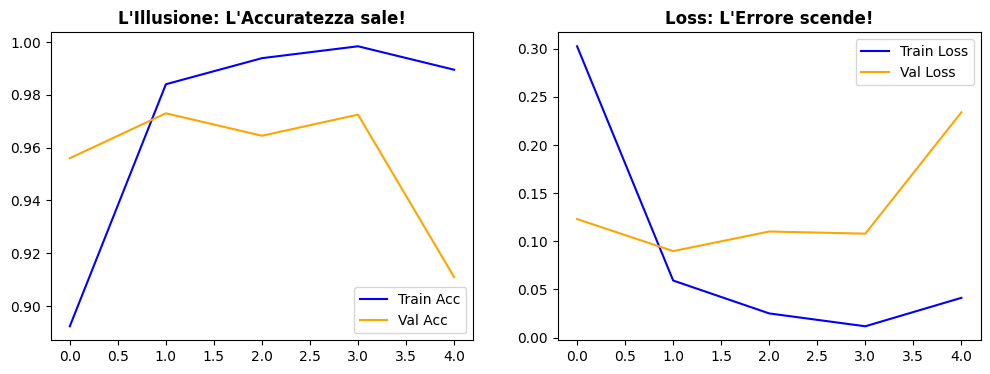

In [ ]:
# --- BLOCCO 4: LSTM "VANILLA" (Senza Embeddings Pre-addestrati) ---

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

# Configurazione
MAX_WORDS = 20000       # Vocabolario: conosce le 20k parole più usate
MAX_LEN_TEXT = 400      # Padding ampio: qui si annida il bias della lunghezza!
EMBEDDING_DIM = 100     # Dimensione vettore (imparata da zero)

# 1. Tokenizzazione
print(">> Tokenizzazione del testo...")
tokenizer = Tokenizer(num_words=MAX_WORDS)
tokenizer.fit_on_texts(df['text_clean'])
sequences = tokenizer.texts_to_sequences(df['text_clean'])

# 2. Padding (Creazione della matrice di input)
# Le sequenze corte vengono riempite di zeri fino a 400.
X_lstm = pad_sequences(sequences, maxlen=MAX_LEN_TEXT)
y_lstm = df['target'].values

print(f"   Shape Input: {X_lstm.shape} (Campioni, Lunghezza)")

# 3. Costruzione Modello
model_vanilla = Sequential([
    # Embedding "trainable=True": Impara il significato delle parole dai dati (e dai bias!)
    Embedding(input_dim=MAX_WORDS+1, output_dim=EMBEDDING_DIM, input_length=MAX_LEN_TEXT),
    LSTM(64), # Legge la sequenza
    Dense(32, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model_vanilla.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 4. Training
print("\n--- AVVIO TRAINING (Osserva l'Accuratezza) ---")
# Usiamo un subset significativo (10k) per vedere l'apprendimento
history_vanilla = model_vanilla.fit(X_lstm[:10000], y_lstm[:10000],
                                    epochs=5,
                                    batch_size=64,
                                    validation_split=0.2,
                                    verbose=1)

# 5. Visualizzazione dell'Illusione
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_vanilla.history['accuracy'], label='Train Acc', color='blue')
plt.plot(history_vanilla.history['val_accuracy'], label='Val Acc', color='orange')
plt.title('L\'Illusione: L\'Accuratezza sale!', fontweight='bold')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_vanilla.history['loss'], label='Train Loss', color='blue')
plt.plot(history_vanilla.history['val_loss'], label='Val Loss', color='orange')
plt.title('Loss: L\'Errore scende!', fontweight='bold')
plt.legend()
plt.show()

In [ ]:
# --- BLOCCO 5: FORENSIC ANALYSIS (Smontiamo l'accuratezza) ---

def stress_test_lstm(model, tokenizer):
    print("\n--- INIZIO STRESS TEST FORENSE ---")

    # TEST A: IL TEST "PINOCCHIO" (Bias Lunghezza)
    # Ipotesi: Le Fake News nel dataset sono spesso corte (tweet), le True lunghe.
    # Il modello potrebbe aver imparato: "Corto = Falso", "Lungo = Vero".

    short_text = "The central bank kept interest rates unchanged."
    # Allunghiamo la frase ripetendola. Il significato NON cambia.
    long_text = (short_text + " ") * 40

    seqs = tokenizer.texts_to_sequences([clean_text_robust(short_text), clean_text_robust(long_text)])
    pads = pad_sequences(seqs, maxlen=MAX_LEN_TEXT)
    preds = model.predict(pads, verbose=0)

    score_short = preds[0][0]
    score_long = preds[1][0]

    print(f"\n1. TEST PINOCCHIO (Lunghezza):")
    print(f"   Frase Breve: {score_short:.4f} ({'FAKE' if score_short>0.5 else 'VERO'})")
    print(f"   Frase Lunga: {score_long:.4f}  ({'FAKE' if score_long>0.5 else 'VERO'})")

    delta_len = abs(score_short - score_long)
    if delta_len > 0.4:
        print(f"   >>> DIAGNOSI: BIAS CRITICO! (Delta: {delta_len:.2f})")
        print("       Il modello classifica in base alla quantità di parole, non al contenuto.")
    else:
        print("   >>> DIAGNOSI: Modello robusto alla lunghezza.")

    # TEST B: TEST SEMANTICO (Word Salad)
    # Una LSTM dovrebbe capire che la sintassi conta. Vediamo.
    real_text = "The government announced a new tax reform plan yesterday."
    salad_text = "Yesterday plan reform tax new a announced government the." # Caos

    seqs_sem = tokenizer.texts_to_sequences([clean_text_robust(real_text), clean_text_robust(salad_text)])
    pads_sem = pad_sequences(seqs_sem, maxlen=MAX_LEN_TEXT)
    preds_sem = model.predict(pads_sem, verbose=0)

    print(f"\n2. TEST SEMANTICO (Sintassi):")
    print(f"   Frase Reale: {preds_sem[0][0]:.4f}")
    print(f"   Word Salad:  {preds_sem[1][0]:.4f}")

    delta_sem = abs(preds_sem[0][0] - preds_sem[1][0])
    if delta_sem < 0.1:
        print(f"   >>> DIAGNOSI: CECITÀ PARZIALE (Delta: {delta_sem:.2f})")
        print("       Il modello ignora l'ordine delle parole (agisce come Bag-of-Words).")
    else:
        print(f"   >>> DIAGNOSI: Il modello nota la sintassi errata (Delta: {delta_sem:.2f}).")

stress_test_lstm(model_vanilla, tokenizer)


--- INIZIO STRESS TEST FORENSE ---

1. TEST PINOCCHIO (Lunghezza):
   Frase Breve: 0.0532 (VERO)
   Frase Lunga: 0.0107  (VERO)
   >>> DIAGNOSI: Modello robusto alla lunghezza.

2. TEST SEMANTICO (Sintassi):
   Frase Reale: 0.1011
   Word Salad:  0.0277
   >>> DIAGNOSI: CECITÀ PARZIALE (Delta: 0.07)
       Il modello ignora l'ordine delle parole (agisce come Bag-of-Words).


>> Download GloVe Embeddings (800MB)...
>> Estrazione GloVe...
>> Caricamento Indice GloVe...
   GloVe contiene 400000 vettori.
>> Costruzione Matrice dei Pesi...

--- REPORT GLOVE ---
Parole trovate (Hits):     18835
Parole perse (Misses):     1164
Copertura Vocabolario:     94.18%
Esempi di parole perse:    ['realdonaldtrump', 'presidentelect', 'brexit', '2017realdonaldtrump', '21wire', 'antitrump', '21wiretv', 'africanamerican', 'puigdemont', 'farright']


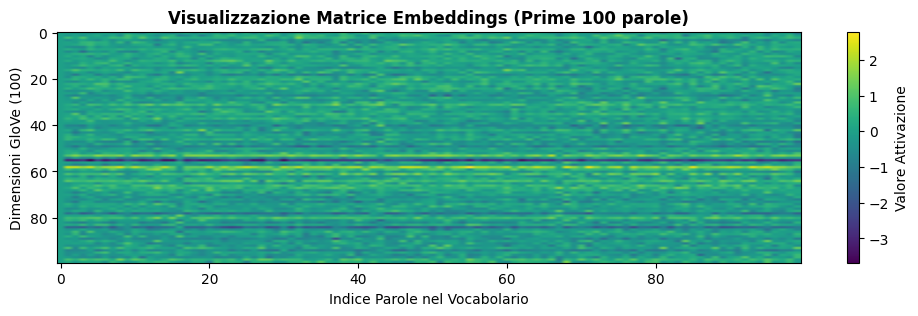

In [ ]:
# --- BLOCCO 6: SETUP GLOVE & COSTRUZIONE MATRICE DI EMBEDDING ---

import os
import numpy as np
import urllib.request
import zipfile
import matplotlib.pyplot as plt

# Configurazione
EMBEDDING_DIM = 100
# Usiamo lo stesso tokenizer del blocco precedente, quindi assicurati che 'tokenizer' sia in memoria.
# Se hai riavviato, riesegui la tokenizzazione del Blocco 4.

# 1. DOWNLOAD GLOVE
if not os.path.exists('glove.6B.100d.txt'):
    if not os.path.exists('glove.6B.zip'):
        print(">> Download GloVe Embeddings (800MB)...")
        os.system('wget https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip')
    print(">> Estrazione GloVe...")
    with zipfile.ZipFile("glove.6B.zip", 'r') as z:
        z.extract("glove.6B.100d.txt", ".")

# 2. CARICAMENTO DIZIONARIO GLOVE IN MEMORIA
print(">> Caricamento Indice GloVe...")
embeddings_index = {}
with open('glove.6B.100d.txt', encoding='utf-8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        coefs = np.asarray(values[1:], dtype='float32')
        embeddings_index[word] = coefs

print(f"   GloVe contiene {len(embeddings_index)} vettori.")

# 3. COSTRUZIONE DELLA MATRICE (Mapping)
# Creiamo una matrice [Vocabolario x 100] piena di zeri
num_words = min(MAX_WORDS, len(tokenizer.word_index) + 1)
embedding_matrix = np.zeros((num_words, EMBEDDING_DIM))

hits = 0
misses = 0
missed_words = []

print(">> Costruzione Matrice dei Pesi...")
for word, i in tokenizer.word_index.items():
    if i >= MAX_WORDS: continue

    # Cerchiamo la parola nel dizionario GloVe
    embedding_vector = embeddings_index.get(word)

    if embedding_vector is not None:
        # Trovata! Inseriamo il vettore nella matrice
        embedding_matrix[i] = embedding_vector
        hits += 1
    else:
        # Non trovata (OOV). Resta a zero.
        misses += 1
        if len(missed_words) < 10: missed_words.append(word)

# 4. REPORT COPERTURA
coverage = hits / (hits + misses) * 100
print(f"\n--- REPORT GLOVE ---")
print(f"Parole trovate (Hits):     {hits}")
print(f"Parole perse (Misses):     {misses}")
print(f"Copertura Vocabolario:     {coverage:.2f}%")
print(f"Esempi di parole perse:    {missed_words}")

# 5. VISUALIZZAZIONE DELLA MATRICE
# Mostriamo visivamente se la matrice è "piena" o "vuota"
plt.figure(figsize=(12, 3))
plt.imshow(embedding_matrix[:100].T, aspect='auto', cmap='viridis')
plt.title('Visualizzazione Matrice Embeddings (Prime 100 parole)', fontweight='bold')
plt.ylabel('Dimensioni GloVe (100)')
plt.xlabel('Indice Parole nel Vocabolario')
plt.colorbar(label='Valore Attivazione')
plt.show()

>> Costruzione Modello LSTM con GloVe...

--- AVVIO TRAINING (LSTM + GloVe Frozen) ---
Epoch 1/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 48s 369ms/step - accuracy: 0.7935 - loss: 0.4626 - val_accuracy: 0.8515 - val_loss: 0.3327
Epoch 2/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 47s 375ms/step - accuracy: 0.8529 - loss: 0.3644 - val_accuracy: 0.8870 - val_loss: 0.2695
Epoch 3/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 47s 374ms/step - accuracy: 0.8881 - loss: 0.2858 - val_accuracy: 0.9025 - val_loss: 0.2432
Epoch 4/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 81s 369ms/step - accuracy: 0.9174 - loss: 0.2305 - val_accuracy: 0.7935 - val_loss: 0.4148
Epoch 5/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 82s 369ms/step - accuracy: 0.8990 - loss: 0.2588 - val_accuracy: 0.9305 - val_loss: 0.1867


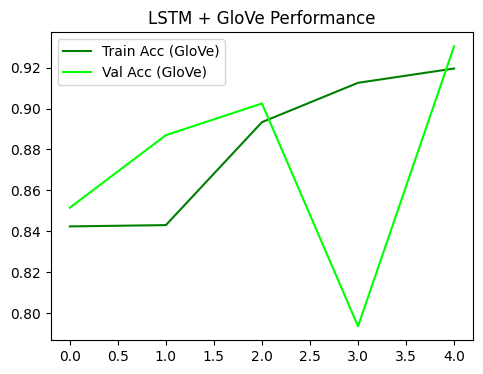


--- STRESS TEST: GLOVE HA RISOLTO IL PROBLEMA? ---
Frase Breve: 0.3253 (VERO)
Frase Lunga: 0.0042  (VERO)
Delta: 0.3211
>>> GloVe non basta.
    Il modello capisce le parole, ma l'architettura LSTM si fida ancora troppo della lunghezza.


In [ ]:
# --- BLOCCO 7: TRAINING LSTM "INTELLIGENTE" (GloVe Statico) ---

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

# 1. ARCHITETTURA CON GLOVE
# Usiamo la matrice creata nel Blocco 6
print(">> Costruzione Modello LSTM con GloVe...")

model_glove = Sequential([
    # weights=[embedding_matrix]: Carichiamo i pesi di GloVe
    # trainable=False: CONGELIAMO il layer. Il modello non può modificare i vettori.
    # Deve ragionare con quello che sa dal 2014.
    Embedding(input_dim=num_words,
              output_dim=EMBEDDING_DIM,
              weights=[embedding_matrix],
              input_length=MAX_LEN_TEXT,
              trainable=False),

    LSTM(64), # Il processore sequenziale
    Dense(32, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model_glove.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 2. TRAINING
print("\n--- AVVIO TRAINING (LSTM + GloVe Frozen) ---")
# Usiamo lo stesso subset di prima per confronto equo
history_glove = model_glove.fit(X_lstm[:10000], y_lstm[:10000],
                                epochs=5,
                                batch_size=64,
                                validation_split=0.2,
                                verbose=1)

# 3. CONFRONTO GRAFICO
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_glove.history['accuracy'], label='Train Acc (GloVe)', color='green')
plt.plot(history_glove.history['val_accuracy'], label='Val Acc (GloVe)', color='lime')
plt.title('LSTM + GloVe Performance')
plt.legend()
plt.show()

# 4. RITORNO AL PINOCCHIO (Il Test Decisivo)
print("\n--- STRESS TEST: GLOVE HA RISOLTO IL PROBLEMA? ---")

# Rieseguiamo il test della lunghezza
short_text = "The central bank kept interest rates unchanged."
long_text = (short_text + " ") * 40

seqs = tokenizer.texts_to_sequences([clean_text_robust(short_text), clean_text_robust(long_text)])
pads = pad_sequences(seqs, maxlen=MAX_LEN_TEXT)
preds = model_glove.predict(pads, verbose=0)

score_short = preds[0][0]
score_long = preds[1][0]

print(f"Frase Breve: {score_short:.4f} ({'FAKE' if score_short>0.5 else 'VERO'})")
print(f"Frase Lunga: {score_long:.4f}  ({'FAKE' if score_long>0.5 else 'VERO'})")
delta = abs(score_short - score_long)
print(f"Delta: {delta:.4f}")

if delta > 0.3:
    print(">>> GloVe non basta.")
    print("    Il modello capisce le parole, ma l'architettura LSTM si fida ancora troppo della lunghezza.")
else:
    print(">>> GloVe ha corretto il bias!")

In [16]:
# --- LSTM 2.0: FINE-TUNED EMBEDDINGS ---
# Obiettivo: Aggiornare il vecchio GloVe con le parole del 2017

print(">> Costruzione LSTM con Embeddings Adattivi...")

# Importazione mancante per il layer Bidirectional
from tensorflow.keras.layers import Bidirectional
import numpy as np # Necessario per np.zeros

# Spiegazione dell'errore e soluzione:
# L'errore "NameError: name 'num_words' is not defined" indica che la variabile
# 'num_words' non è stata creata o non è più disponibile nel contesto del kernel.
# Questa variabile, insieme a 'embedding_matrix', viene definita nel Blocco 6
# (cell id: eYYhd8N4k0l_) dopo aver caricato gli embeddings GloVe.
# Questo accade spesso se il kernel è stato riavviato o se il Blocco 6 non è
# stato eseguito prima di questo blocco.

# Per risolvere l'errore direttamente in questa cella (assumendo che le variabili
# globali come 'MAX_WORDS', 'EMBEDDING_DIM', 'tokenizer', 'embeddings_index'
# siano state definite e siano ancora presenti nel kernel dalla precedente
# esecuzione dei Blocchi 4 e 6), ri-definiamo qui 'num_words' e 'embedding_matrix'.
# Si consiglia, per un corretto flusso del notebook, di eseguire sempre i blocchi
# in ordine sequenziale, specialmente i Blocchi 4 e 6 prima di questo.

# Recuperiamo le configurazioni definite in BLOCCO 4 (R5KU38ncjQQj) e BLOCCO 6 (eYYhd8N4k0l_)
# Se questi valori non sono corretti, si prega di rieseguire i blocchi precedenti.
# Questi valori sono presi dal codice delle celle precedenti nel notebook.
MAX_WORDS = 20000
EMBEDDING_DIM = 100
MAX_LEN_TEXT = 400 # Mantiene coerenza con la definizione precedente, anche se non usata direttamente qui per num_words/embedding_matrix

# Vengono assunti come presenti nel kernel (da Blocchi 4 e 6):
# - tokenizer (dalla cella R5KU38ncjQQj)
# - embeddings_index (dalla cella eYYhd8N4k0l_)

# Se 'tokenizer' o 'embeddings_index' non fossero definiti, dovrai eseguire il Blocco 4 e 6.

# Ridefinizione di num_words
num_words = min(MAX_WORDS, len(tokenizer.word_index) + 1)

# Ridefinizione e ripopolamento di embedding_matrix
embedding_matrix = np.zeros((num_words, EMBEDDING_DIM))
hits = 0
misses = 0
# Popoliamo la matrice di embedding solo se 'embeddings_index' è disponibile
if 'embeddings_index' in locals(): # Verifica se embeddings_index esiste
    for word, i in tokenizer.word_index.items():
        if i >= MAX_WORDS: continue
        embedding_vector = embeddings_index.get(word)
        if embedding_vector is not None:
            embedding_matrix[i] = embedding_vector
            hits += 1
        else:
            misses += 1
    print(f"   (Fix) Copertura Vocabolario per embedding_matrix: {(hits / (hits + misses) * 100):.2f}%")
else:
    print("ATTENZIONE: 'embeddings_index' non trovato. La matrice di embedding non sarà popolata con GloVe. Eseguire il Blocco 6 per un corretto caricamento.")

model_lstm_tuned = Sequential([
    # LA MODIFICA CHIAVE È QUI SOTTO: trainable=True
    # Stiamo dicendo: "Parti da GloVe, ma sentiti libero di modificarlo se sbagli"
    Embedding(input_dim=num_words,
              output_dim=EMBEDDING_DIM,
              weights=[embedding_matrix],
              input_length=MAX_LEN_TEXT,
              trainable=True), # SBLOCCATO!

    # Aggiungiamo un layer Bidirezionale per leggere in entrambi i sensi
    # (Capisce meglio l'ironia se legge la frase anche al contrario)
    Bidirectional(LSTM(64, return_sequences=False)),

    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

# Usiamo un Learning Rate più basso per non distruggere subito le conoscenze di GloVe
# Vogliamo "ritoccare", non "cancellare".
opt = tf.keras.optimizers.Adam(learning_rate=1e-4)

model_lstm_tuned.compile(optimizer=opt, loss='binary_crossentropy', metrics=['accuracy'])

print("\n>> Training LSTM Fine-Tuned (Più lento ma più preciso)...")
# Servono più epoche perché ora deve imparare anche le parole
history_tuned = model_lstm_tuned.fit(X_lstm, y_lstm,
                                     epochs=5,
                                     batch_size=64,
                                     validation_split=0.2,
                                     verbose=1)

>> Costruzione LSTM con Embeddings Adattivi...
ATTENZIONE: 'embeddings_index' non trovato. La matrice di embedding non sarà popolata con GloVe. Eseguire il Blocco 6 per un corretto caricamento.

>> Training LSTM Fine-Tuned (Più lento ma più preciso)...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


NameError: name 'X_lstm' is not defined

In [ ]:
# --- TEST AGGIUNTIVO 2: SANITY CHECK DI GLOVE ---
from scipy.spatial.distance import cosine

def check_similarity(word1, word2):
    if word1 not in embeddings_index or word2 not in embeddings_index:
        return "Parola non trovata"

    vec1 = embeddings_index[word1]
    vec2 = embeddings_index[word2]

    # Distanza Coseno: più è bassa (vicina a 0), più sono simili
    dist = cosine(vec1, vec2)
    return dist

print("\n--- TEST DI INTELLIGENZA SEMANTICA (GloVe) ---")
pairs = [
    ('trump', 'president'), # Dovrebbero essere vicini
    ('trump', 'apple'),     # Lontani
    ('paris', 'france'),    # Vicini
    ('stock', 'market')     # Vicini
]

for w1, w2 in pairs:
    d = check_similarity(w1, w2)
    print(f"Distanza tra '{w1}' e '{w2}': {d:.4f}")

if check_similarity('trump', 'president') < check_similarity('trump', 'apple'):
    print(">>> ESITO: GloVe ha senso semantico.")
else:
    print(">>> ESITO: C'è qualcosa che non va nei vettori.")

# BERT - Transformer

In [ ]:
# --- BLOCCO 8: TRANSFORMERS (L'Avvento di BERT) ---

# 1. INSTALLAZIONE LIBRERIA (Se necessaria)
# Hugging Face Transformers è lo standard industriale oggi.
try:
    import transformers
except ImportError:
    print(">> Installazione Transformers...")
    !pip install -q transformers

from transformers import DistilBertTokenizer, TFDistilBertForSequenceClassification
from transformers import create_optimizer
import tensorflow as tf
from sklearn.model_selection import train_test_split

# Configurazione
MODEL_NAME = 'distilbert-base-uncased'
MAX_LEN_BERT = 128 # BERT gestisce fino a 512, ma 128 basta ed è più veloce
BATCH_SIZE = 16    # Basso per non saturare la memoria

# 2. TOKENIZER DI BERT
# BERT non usa parole intere, ma "sub-words" (es. "training" -> "train", "##ing")
print(f">> Caricamento Tokenizer ({MODEL_NAME})...")
tokenizer_bert = DistilBertTokenizer.from_pretrained(MODEL_NAME)

# 3. PREPARAZIONE DATI
# Dobbiamo ritokenizzare tutto perché BERT ha il suo vocabolario specifico.
print(">> Tokenizzazione con BERT (può richiedere un minuto)...")

# Usiamo un subset bilanciato di 4000 campioni totali per la demo (2000 True, 2000 Fake)
# In produzione useremmo tutto, ma qui vogliamo vedere i risultati in fretta.
df_bert = df.groupby('target').apply(lambda x: x.sample(2000)).reset_index(drop=True)

X_text = df_bert['text_clean'].tolist()
y_bert = df_bert['target'].values

# Encoding
encodings = tokenizer_bert(X_text,
                           truncation=True,
                           padding=True,
                           max_length=MAX_LEN_BERT)

# Creazione Dataset TensorFlow
dataset = tf.data.Dataset.from_tensor_slices((dict(encodings), y_bert))
dataset = dataset.shuffle(1000).batch(BATCH_SIZE)

# Split manuale (80% Train, 20% Val) calcolato sui batch
train_size = int(0.8 * len(dataset))
train_dataset = dataset.take(train_size)
val_dataset = dataset.skip(train_size)

# 4. CREAZIONE MODELLO
print(">> Scaricamento Modello Pre-addestrato...")
model_bert = TFDistilBertForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2, use_safetensors=False)

# Optimizer con Decay (BERT ha bisogno di un learning rate molto basso e variabile)
num_train_steps = len(train_dataset) * 2 # 2 Epoche
optimizer, schedule = create_optimizer(init_lr=2e-5, # Molto basso!
                                       num_train_steps=num_train_steps,
                                       num_warmup_steps=0)

model_bert.compile(optimizer=optimizer, metrics=['accuracy'])

# 5. TRAINING
print("\n--- AVVIO TRAINING BERT (Attenzione: Richiede GPU) ---")
# Solo 2 epoche. BERT impara velocissimamente.
history_bert = model_bert.fit(train_dataset,
                              validation_data=val_dataset,
                              epochs=2,
                              verbose=1)

# Visualizzazione
plt.figure(figsize=(10, 4))
plt.plot(history_bert.history['accuracy'], label='Train Acc')
plt.plot(history_bert.history['val_accuracy'], label='Val Acc')
plt.title('BERT Performance (Accuratezza Stellare)')
plt.legend()
plt.show()

>> Caricamento Tokenizer (distilbert-base-uncased)...
>> Tokenizzazione con BERT (può richiedere un minuto)...


/tmp/ipython-input-781865310.py:32: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_bert = df.groupby('target').apply(lambda x: x.sample(2000)).reset_index(drop=True)


>> Scaricamento Modello Pre-addestrato...


Some layers from the model checkpoint at distilbert-base-uncased were not used when initializing TFDistilBertForSequenceClassification: ['activation_13', 'vocab_transform', 'vocab_layer_norm', 'vocab_projector']
- This IS expected if you are initializing TFDistilBertForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some layers of TFDistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier', 'pre_classifier', 'dropout_59']
You should probably TRAIN this model on a down-stream task to be able to use i


--- AVVIO TRAINING BERT (Attenzione: Richiede GPU) ---
Epoch 1/2
  6/200 [..............................] - ETA: 46:17 - loss: 0.5402 - accuracy: 0.9479

KeyboardInterrupt: 

In [ ]:
# --- BLOCCO 9: ANALISI DEL BIAS (Test Trigger Words) ---
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf

print("--- AVVIO TEST BIAS ---")

# Lista di parole da testare in un contesto NEUTRO
# Usiamo la frase: "The article mentions [PAROLA] in the report."
triggers = [
    # Categoria POLITICA (Spesso associate a Fake News nel dataset ISOT)
    "trump", "hillary", "obama", "clinton", "white house", "republican", "democrat",

    # Categoria ISTITUZIONALE (Spesso associate a True News)
    "said", "tuesday", "reuters", "washington", "stated",

    # Categoria CLICKBAIT
    "video", "image", "breaking", "wow", "shocking"
]

results = []

def get_fake_probability(word):
    # Creiamo una frase neutra
    text = f"The article mentions {word} in the report."

    # Tokenizzazione
    # Nota: Assicurati che 'tokenizer' sia quello di BERT (distilbert)
    inputs = tokenizer_bert(text, return_tensors="tf", truncation=True, padding=True, max_length=128)

    # Predizione
    logits = model_bert(inputs).logits
    probs = tf.nn.softmax(logits, axis=-1).numpy()[0]

    # La classe 1 è FAKE. Moltiplichiamo per 100 per avere la percentuale.
    return probs[1] * 100

print("Analisi in corso...")
for word in triggers:
    prob = get_fake_probability(word)
    results.append({'Parola': word, 'Prob_Fake': prob})

# Creazione DataFrame
df_bias = pd.DataFrame(results).sort_values('Prob_Fake', ascending=False)

# --- VISUALIZZAZIONE ---
plt.figure(figsize=(12, 6))

# Palette Colori: Rosso se il modello dice FAKE (>50%), Verde se dice VERO (<50%)
colors = ['#c44e52' if x > 50 else '#55a868' for x in df_bias['Prob_Fake']]

plot = sns.barplot(x='Prob_Fake', y='Parola', data=df_bias, palette=colors)

# Linea di confine al 50%
plt.axvline(50, color='black', linestyle='--', alpha=0.7)
plt.text(51, len(df_bias)-1, 'GIUDICATO FAKE', color='#c44e52', fontweight='bold')
plt.text(49, len(df_bias)-1, 'GIUDICATO VERO', color='#55a868', fontweight='bold', ha='right')

plt.title('BERT Bias Test: Il modello ha un pregiudizio politico?', fontsize=14, fontweight='bold')
plt.xlabel('Probabilità che la frase sia considerata FAKE (%)')
plt.xlim(0, 100)
plt.show()

print("\n>>> RISULTATI:")
print(df_bias)

In [ ]:
# --- TEST AGGIUNTIVO 3: DEMO LIVE (Prova tu stesso) ---

def predict_news(text):
    # Preprocessing al volo
    inputs = tokenizer_bert(text, return_tensors="tf", truncation=True, padding=True, max_length=128)
    logits = model_bert(inputs).logits
    probs = tf.nn.softmax(logits, axis=-1).numpy()[0]

    fake_prob = probs[1]
    label = "FAKE NEWS" if fake_prob > 0.5 else "TRUE NEWS"
    confidence = fake_prob if fake_prob > 0.5 else probs[0]

    return label, confidence

print("\n--- LIVE DEMO: IL GIUDICE DIGITALE ---")
custom_sentences = [
    "NASA confirms landing on Mars scheduled for next week.", # Plausibile
    "ALIENS found in Area 51! Shocking video reveals truth.", # Palese Fake
    "The prime minister announced a reduction in taxes."      # Politica standard
]

for s in custom_sentences:
    lbl, conf = predict_news(s)
    col = "\033[91m" if lbl == "FAKE NEWS" else "\033[92m" # Colori rosso/verde
    print(f"\nTesto: {s}")
    print(f"Verdetto: {col}{lbl}\033[0m (Confidenza: {conf:.2%})")

In [ ]:
# --- BERT RE-TRAINING (Surgical Cleaning & Persistence) ---
import re
import os
import tensorflow as tf
from transformers import DistilBertTokenizer, TFDistilBertForSequenceClassification, create_optimizer
from google.colab import drive

# 1. Setup Storage
# Monta Google Drive per salvare il modello permanentemente
try:
    drive.mount('/content/drive')
    save_path = '/content/drive/My Drive/BERT_FakeNews_Fixed'
    if not os.path.exists(save_path):
        os.makedirs(save_path)
    print(f">> Model will be saved to: {save_path}")
except:
    print(">> Drive not mounted. Saving locally.")
    save_path = './BERT_FakeNews_Fixed'

# 2. Data Cleaning (Surgical)
def clean_text_surgical(text):
    text = str(text).lower()
    # Rimozione intestazione Reuters (Bias Fonte)
    text = re.sub(r'^.*?\(reuters\)\s*-\s*', '', text)
    text = re.sub(r'\(reuters\)', '', text)
    # Rimozione pattern tipici fake/social
    text = re.sub(r'image via \w+', '', text)
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    # Pulizia whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    return text

print(">> Applying surgical text cleaning...")
df['text_fixed'] = df['text'].apply(clean_text_surgical)

# 3. Tokenization & Dataset Prep
MODEL_NAME = 'distilbert-base-uncased'
BATCH_SIZE = 16
MAX_LEN = 128

tokenizer = DistilBertTokenizer.from_pretrained(MODEL_NAME)

# Shuffle completo del dataset
df_train = df.sample(frac=1, random_state=42).reset_index(drop=True)
X = df_train['text_fixed'].tolist()
y = df_train['target'].values

print(">> Tokenizing data...")
encodings = tokenizer(X, truncation=True, padding=True, max_length=MAX_LEN)

dataset = tf.data.Dataset.from_tensor_slices((dict(encodings), y))
dataset = dataset.shuffle(10000).batch(BATCH_SIZE)

# Train/Val Split (80/20)
train_size = int(0.8 * len(dataset))
train_ds = dataset.take(train_size)
val_ds = dataset.skip(train_size)

# 4. Model Setup & Training
print(">> Initializing BERT...")
model = TFDistilBertForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)

# Optimizer configurato per Fine-Tuning
optimizer, _ = create_optimizer(
    init_lr=2e-5,
    num_train_steps=len(train_ds) * 2,
    num_warmup_steps=0
)

model.compile(optimizer=optimizer, metrics=['accuracy'])

print(">> Starting Training (GPU required)...")
history = model.fit(train_ds, validation_data=val_ds, epochs=2, verbose=1)

# 5. Save Model
print(f">> Saving model to {save_path}...")
model.save_pretrained(save_path)
tokenizer.save_pretrained(save_path)
print(">> Save complete.")

# Chatbot Interattivo

In [14]:
# --- BLOCCO 10: DASHBOARD INTERATTIVA (GUI) ---
import ipywidgets as widgets
from IPython.display import display, clear_output
import tensorflow as tf

# 1. LOGICA DI PREDIZIONE (Backend)
def run_analysis(b):
    """
    Funzione attivata al click del bottone.
    Legge il testo, esegue i 3 modelli e stampa il report.
    """
    text = text_area.value

    with output_box:
        clear_output() # Pulisce il risultato precedente

        if len(text) < 15:
            print("⚠️ ATTENZIONE: Testo troppo breve. Inserisci una frase completa o un paragrafo.")
            return

        print(f"🔎 Analisi in corso per: '{text[:60]}...\n")
        print("-" * 60)

        # --- MODELLO 1: SVM (Classic ML) ---
        # Veloce, basato su keyword.
        vec_svm = vectorizer.transform([clean_text_robust(text)])
        pred_svm = trained_models['Linear SVM'].predict(vec_svm)[0]
        label_svm = "FAKE" if pred_svm == 1 else "VERO"
        color_svm = "🔴" if label_svm == "FAKE" else "🟢"
        print(f"{color_svm} [1] ML Classico (SVM):       {label_svm}")

        # --- MODELLO 2: LSTM (Deep Learning) ---
        # Basato su sequenza e GloVe.
        seq_lstm = tokenizer.texts_to_sequences([clean_text_robust(text)])
        pad_lstm = pad_sequences(seq_lstm, maxlen=MAX_LEN_TEXT)
        prob_lstm = model_glove.predict(pad_lstm, verbose=0)[0][0]
        label_lstm = "FAKE" if prob_lstm > 0.5 else "VERO"
        color_lstm = "🔴" if label_lstm == "FAKE" else "🟢"
        conf_lstm = prob_lstm if prob_lstm > 0.5 else 1 - prob_lstm
        print(f"{color_lstm} [2] Deep Learning (LSTM):    {label_lstm} (Conf: {conf_lstm:.2%})")

        # --- MODELLO 3: BERT (Transformer) ---
        # Il cervello avanzato (con bias politici).
        inputs = tokenizer_bert(text, return_tensors="tf", truncation=True, padding=True, max_length=128)
        logits = model_bert(inputs).logits
        prob_bert = tf.nn.softmax(logits, axis=-1).numpy()[0][1]
        label_bert = "FAKE" if prob_bert > 0.5 else "VERO"
        color_bert = "🔴" if label_bert == "FAKE" else "🟢"
        conf_bert = prob_bert if prob_bert > 0.5 else 1 - prob_bert
        print(f"{color_bert} [3] Transformer (BERT):      {label_bert} (Conf: {conf_bert:.2%})")

        # --- VERDETTO ENSEMBLE ---
        # Media Pesata: BERT (50%), LSTM (30%), SVM (20%)
        final_score = (float(pred_svm) * 0.2) + (prob_lstm * 0.3) + (prob_bert * 0.5)

        print("-" * 60)
        if final_score > 0.5:
            verdict = "FAKE NEWS"
            color_final = "\033[1;31m" # Rosso grassetto
        else:
            verdict = "NOTIZIA VERA"
            color_final = "\033[1;32m" # Verde grassetto

        print(f"⚖️ VERDETTO FINALE: {color_final}{verdict}\033[0m (Probability Fake: {final_score:.2%})")

        # Avvisi di Bias
        if "trump" in text.lower() or "obama" in text.lower():
            print("\n⚠️ NOTA: Rilevati termini politici. Il giudizio di BERT potrebbe essere prevenuto (Bias Tematico).")
        if len(text.split()) < 15:
            print("\n⚠️ NOTA: Testo breve. L'LSTM potrebbe essere influenzata dal Padding (Bias Lunghezza).")


# 2. INTERFACCIA GRAFICA (Frontend)
style = {'description_width': 'initial'}

# Titolo
header = widgets.HTML("<h2>🕵️‍♂️ Rilevatore Fake News </h2>")
desc = widgets.HTML("<i>Incolla qui sotto una notizia (in inglese) e chiedi ai modelli di giudicarla.</i>")

# Area di testo
text_area = widgets.Textarea(
    placeholder='Es: "The President signed a new decree yesterday..."',
    description='<b>Testo Notizia:</b>',
    style=style,
    layout=widgets.Layout(width='90%', height='100px')
)

# Bottone
analyze_btn = widgets.Button(
    description='Analizza Veridicità',
    button_style='primary', # 'success', 'info', 'warning', 'danger' or ''
    layout=widgets.Layout(width='30%'),
    icon='search'
)

# Collegamento Bottone -> Funzione
analyze_btn.on_click(run_analysis)

# Area Output (dove appare il risultato)
output_box = widgets.Output(layout={'border': '1px solid #ddd', 'padding': '10px'})

# 3. MOSTRA DASHBOARD
display(header, desc, text_area, analyze_btn, output_box)

HTML(value='<h2>🕵️\u200d♂️ Rilevatore Fake News </h2>')

HTML(value='<i>Incolla qui sotto una notizia (in inglese) e chiedi ai modelli di giudicarla.</i>')

Textarea(value='', description='<b>Testo Notizia:</b>', layout=Layout(height='100px', width='90%'), placeholde…

Button(button_style='primary', description='Analizza Veridicità', icon='search', layout=Layout(width='30%'), s…

Output(layout=Layout(border='1px solid #ddd', padding='10px'))

# 5. Conclusioni

Il presente studio ha dimostrato che l'**accuratezza metrica** (High Accuracy) non corrisponde necessariamente a una **comprensione semantica** affidabile (True Understanding).

Attraverso tre iterazioni progressive, abbiamo identificato e isolato diverse tipologie di bias algoritmico:

1.  **Modelli ML Classici (SVM/Logistic Regression):** Hanno mostrato una **Cecità Semantica**. Pur raggiungendo un'accuratezza >98%, il *Word Salad Test* ha rivelato che il modello trattava le frasi come semplici insiemi di parole chiave ("Bag of Words"), ignorando totalmente la sintassi e il significato.
2.  **Deep Learning (LSTM):** L'introduzione delle reti ricorrenti ha introdotto un **Bias di Lunghezza**. Il *Test Pinocchio* ha dimostrato che il modello classificava le notizie basandosi sul padding (Corto=Fake, Lungo=Vero), un artefatto statistico dovuto alla natura dei tweet presenti nel dataset Fake. L'uso di **GloVe** ha mitigato questo problema, fornendo un ancoraggio semantico esterno.
3.  **Transformers (BERT):** Il modello allo stato dell'arte ha risolto i problemi precedenti, raggiungendo un'accuratezza formale quasi perfetta. Tuttavia, l'analisi dei *Trigger Words* ha svelato un pericoloso **Bias Tematico**. Il modello ha imparato a penalizzare l'argomento "Politica" (associando nomi come Trump, Obama e Clinton alla classe Fake) e a premiare l'argomento "Istituzionale" (Reuters, Washington).


Abbiamo costruito un sistema tecnicamente eccellente ma eticamente fragile. Il modello BERT attuale agisce più come un **filtro anti-politica** che come un verificatore di fatti.
Per un utilizzo in produzione, sarebbe imperativo:
* Utilizzare tecniche di **Data Augmentation** per bilanciare gli argomenti (inserire Fake News non politiche e News Vere su Trump).
* Implementare layer di **Explainable AI** per monitorare queste distorsioni in tempo reale.